# Detección de Fraude en Transacciones Financieras mediante Análisis de Grafos y Machine Learning

Este cuaderno presenta el flujo completo de entrenamiento de un modelo predictivo para la detección de fraude. 
A diferencia de los enfoques tradicionales, este modelo utiliza **características topológicas** extraídas de una base de datos en grafo (Neo4j), permitiendo capturar el comportamiento de las cuentas dentro de la red financiera.

**Objetivo:** Clasificar transacciones como fraudulentas o legítimas utilizando algoritmos de machine learning sobre un dataset de 6.2 millones de registros.

# Fase 1: Recopilación de los datos

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, OneHotEncoder

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('./df_final.csv')

/tmp/ipykernel_4395/798813054.py:1: DtypeWarning: Columns (3,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./df_final.csv')


# Fase 2: Exploración y preparación de los datos

In [8]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,orig_out_degree,orig_in_degree,orig_pagerank,orig_community,dest_out_degree,dest_in_degree,dest_pagerank,dest_community,isFraud,is_train
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,1.0,0.0,0.15,53200.0,0.0,1.0,0.27750,53200.0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,1.0,0.0,0.15,53201.0,0.0,1.0,0.27750,53201.0,0,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1.0,0.0,0.15,6013326.0,0.0,44.0,5.69625,6013326.0,1,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1.0,0.0,0.15,53203.0,0.0,41.0,5.37750,53203.0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,1.0,0.0,0.15,53204.0,0.0,1.0,0.27750,53204.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,NaN,339682.13,0.00,NaN,0.00,339682.13,0.0,NaN,0.15,-1.0,NaN,1.0,0.27750,5302675.0,1,0
6362616,743,TRANSFER,6311409.28,NaN,6311409.28,0.00,NaN,0.00,0.00,0.0,NaN,0.15,-1.0,NaN,0.0,0.15000,-1.0,1,0
6362617,743,CASH_OUT,6311409.28,NaN,6311409.28,0.00,NaN,68488.84,6379898.11,0.0,NaN,0.15,-1.0,NaN,2.0,0.40500,3613266.0,1,0
6362618,743,TRANSFER,850002.52,NaN,850002.52,0.00,NaN,0.00,0.00,0.0,NaN,0.15,-1.0,NaN,0.0,0.15000,-1.0,1,0


In [9]:
df.shape

(6362620, 19)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 19 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   type             object 
 2   amount           float64
 3   nameOrig         object 
 4   oldbalanceOrg    float64
 5   newbalanceOrig   float64
 6   nameDest         object 
 7   oldbalanceDest   float64
 8   newbalanceDest   float64
 9   orig_out_degree  float64
 10  orig_in_degree   float64
 11  orig_pagerank    float64
 12  orig_community   float64
 13  dest_out_degree  float64
 14  dest_in_degree   float64
 15  dest_pagerank    float64
 16  dest_community   float64
 17  isFraud          int64  
 18  is_train         int64  
dtypes: float64(13), int64(3), object(3)
memory usage: 922.3+ MB


In [11]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_out_degree,orig_in_degree,orig_pagerank,orig_community,dest_out_degree,dest_in_degree,dest_pagerank,dest_community,isFraud,is_train
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.259047e+06,6.362620e+06,6.362620e+06,6.259047e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,9.866105e-01,2.077952e-03,1.502633e-01,3.076528e+06,2.077952e-03,1.109487e+01,1.564917e+00,3.113344e+06,1.290820e-03,9.837216e-01
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,1.375389e-01,1.837657e-01,2.333174e-02,2.540406e+06,4.564231e-02,1.235622e+01,1.576913e+00,2.537155e+06,3.590480e-02,1.265440e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e-01,-1.000000e+00,0.000000e+00,0.000000e+00,1.500000e-01,-1.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.500000e-01,8.448898e+05,0.000000e+00,1.000000e+00,2.775000e-01,8.890850e+05,0.000000e+00,1.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,1.000000e+00,0.000000e+00,1.500000e-01,2.447525e+06,0.000000e+00,7.000000e+00,1.042500e+00,2.490775e+06,0.000000e+00,1.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,1.000000e+00,0.000000e+00,1.500000e-01,4.932562e+06,0.000000e+00,1.700000e+01,2.317500e+00,4.970689e+06,0.000000e+00,1.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,3.000000e+00,5.800000e+01,7.545000e+00,8.924491e+06,2.000000e+00,1.130000e+02,1.455750e+01,8.924491e+06,1.000000e+00,1.000000e+00


## Selección de características

In [12]:
columnas_a_eliminar = [
    'step',
    'nameOrig',
    'nameDest',
    'orig_in_degree',
    'dest_out_degree'
]

df.drop(columns=columnas_a_eliminar, inplace=True)

In [13]:
df

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_out_degree,orig_pagerank,orig_community,dest_in_degree,dest_pagerank,dest_community,isFraud,is_train
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,1.0,0.15,53200.0,1.0,0.27750,53200.0,0,1
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,1.0,0.15,53201.0,1.0,0.27750,53201.0,0,1
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1.0,0.15,6013326.0,44.0,5.69625,6013326.0,1,1
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1.0,0.15,53203.0,41.0,5.37750,53203.0,1,1
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,1.0,0.15,53204.0,1.0,0.27750,53204.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,0.0,0.15,-1.0,1.0,0.27750,5302675.0,1,0
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,0.0,0.15,-1.0,0.0,0.15000,-1.0,1,0
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,0.0,0.15,-1.0,2.0,0.40500,3613266.0,1,0
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,0.0,0.15,-1.0,0.0,0.15000,-1.0,1,0


## Normalización de nombres

In [ ]:
# Definimos el mapeo para origen y destino
nuevos_nombres = {
    'oldbalanceOrg': 'old_balance_orig',
    'newbalanceOrig': 'new_balance_orig',
    'oldbalanceDest': 'old_balance_dest',
    'newbalanceDest': 'new_balance_dest',
    'isFraud': 'is_fraud',
}

# Aplicamos el cambio
df.rename(columns=nuevos_nombres, inplace=True)

# Verificamos el resultado
print("✅ Columnas renombradas correctamente:")
print(df.columns.tolist())

✅ Columnas renombradas correctamente:
['type', 'amount', 'old_balance_orig', 'new_balance_orig', 'old_balance_dest', 'new_balance_dest', 'orig_out_degree', 'orig_pagerank', 'orig_community', 'dest_in_degree', 'dest_pagerank', 'dest_community', 'is_fraud', 'is_train']


## Nulos

In [16]:
print(df.isna().sum())

type                0
amount              0
old_balance_orig    0
new_balance_orig    0
old_balance_dest    0
new_balance_dest    0
orig_out_degree     0
orig_pagerank       0
orig_community      0
dest_in_degree      0
dest_pagerank       0
dest_community      0
is_fraud            0
is_train            0
dtype: int64


## Únicos

In [17]:
print(df['type'].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


## Duplicados

In [19]:
print("Filas duplicadas:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 30
Filas duplicadas: 0


## Correlaciones con la variable objetivo

In [20]:
correlaciones = df.select_dtypes(include=["float64", "int64"]).corr()['is_fraud'].drop('is_fraud')
print(correlaciones)

amount              0.076051
old_balance_orig    0.010026
new_balance_orig   -0.008139
old_balance_dest   -0.005873
new_balance_dest    0.000434
orig_out_degree    -0.046195
orig_pagerank      -0.000405
orig_community      0.006327
dest_in_degree     -0.009521
dest_pagerank      -0.009526
dest_community      0.010175
is_train           -0.050359
Name: is_fraud, dtype: float64


## Distribución por tipo

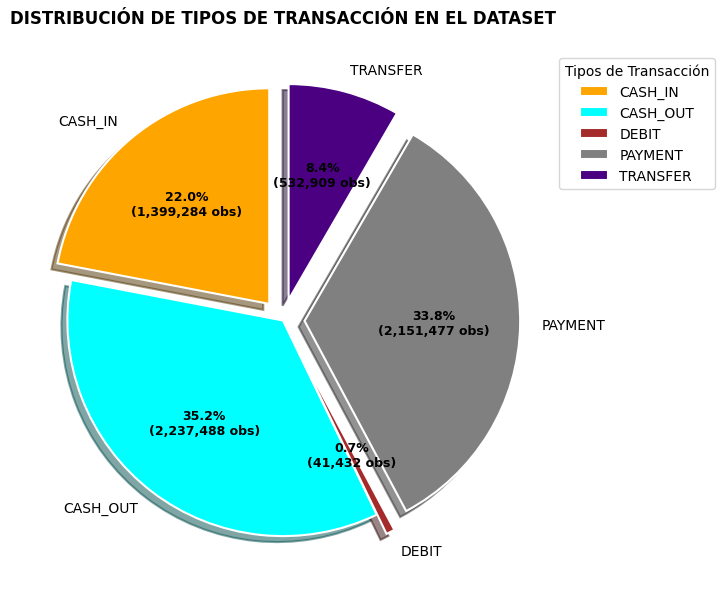

In [21]:
df_gb = df.groupby(['type']).size()
tipos = df_gb.index.values

explode = (0.1, 0.0, 0.1, 0.1, 0.1)
colors = ("orange", "cyan", "brown", "grey", "indigo")
wp = {'linewidth': 1.5, 'edgecolor': "white"}

def func(pct, allvalues):
    absolute = int(round(pct / 100. * np.sum(allvalues)))
    return f"{pct:.1f}%\n({absolute:,} obs)"

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

wedges, texts, autotexts = ax.pie(
    df_gb, 
    autopct=lambda pct: func(pct, df_gb),
    explode=explode, 
    labels=tipos, 
    shadow=True, 
    colors=colors,
    startangle=90, 
    wedgeprops=wp, 
    textprops=dict(color="black")
)

ax.legend(
    wedges, tipos,
    title="Tipos de Transacción",
    loc="upper left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.setp(autotexts, size=9, weight="bold")
ax.set_title("DISTRIBUCIÓN DE TIPOS DE TRANSACCIÓN EN EL DATASET", pad=20, weight="bold")

plt.show()

## Equilibrio

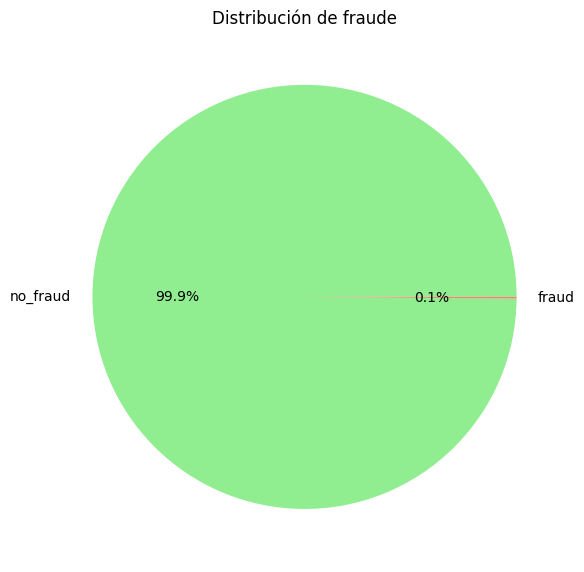

In [22]:
plt.figure(figsize=(6, 6))
df['is_fraud'].map({0: 'no_fraud', 1: 'fraud'}).value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Distribución de fraude')
plt.ylabel("")
plt.tight_layout()
plt.show()

## Outliers

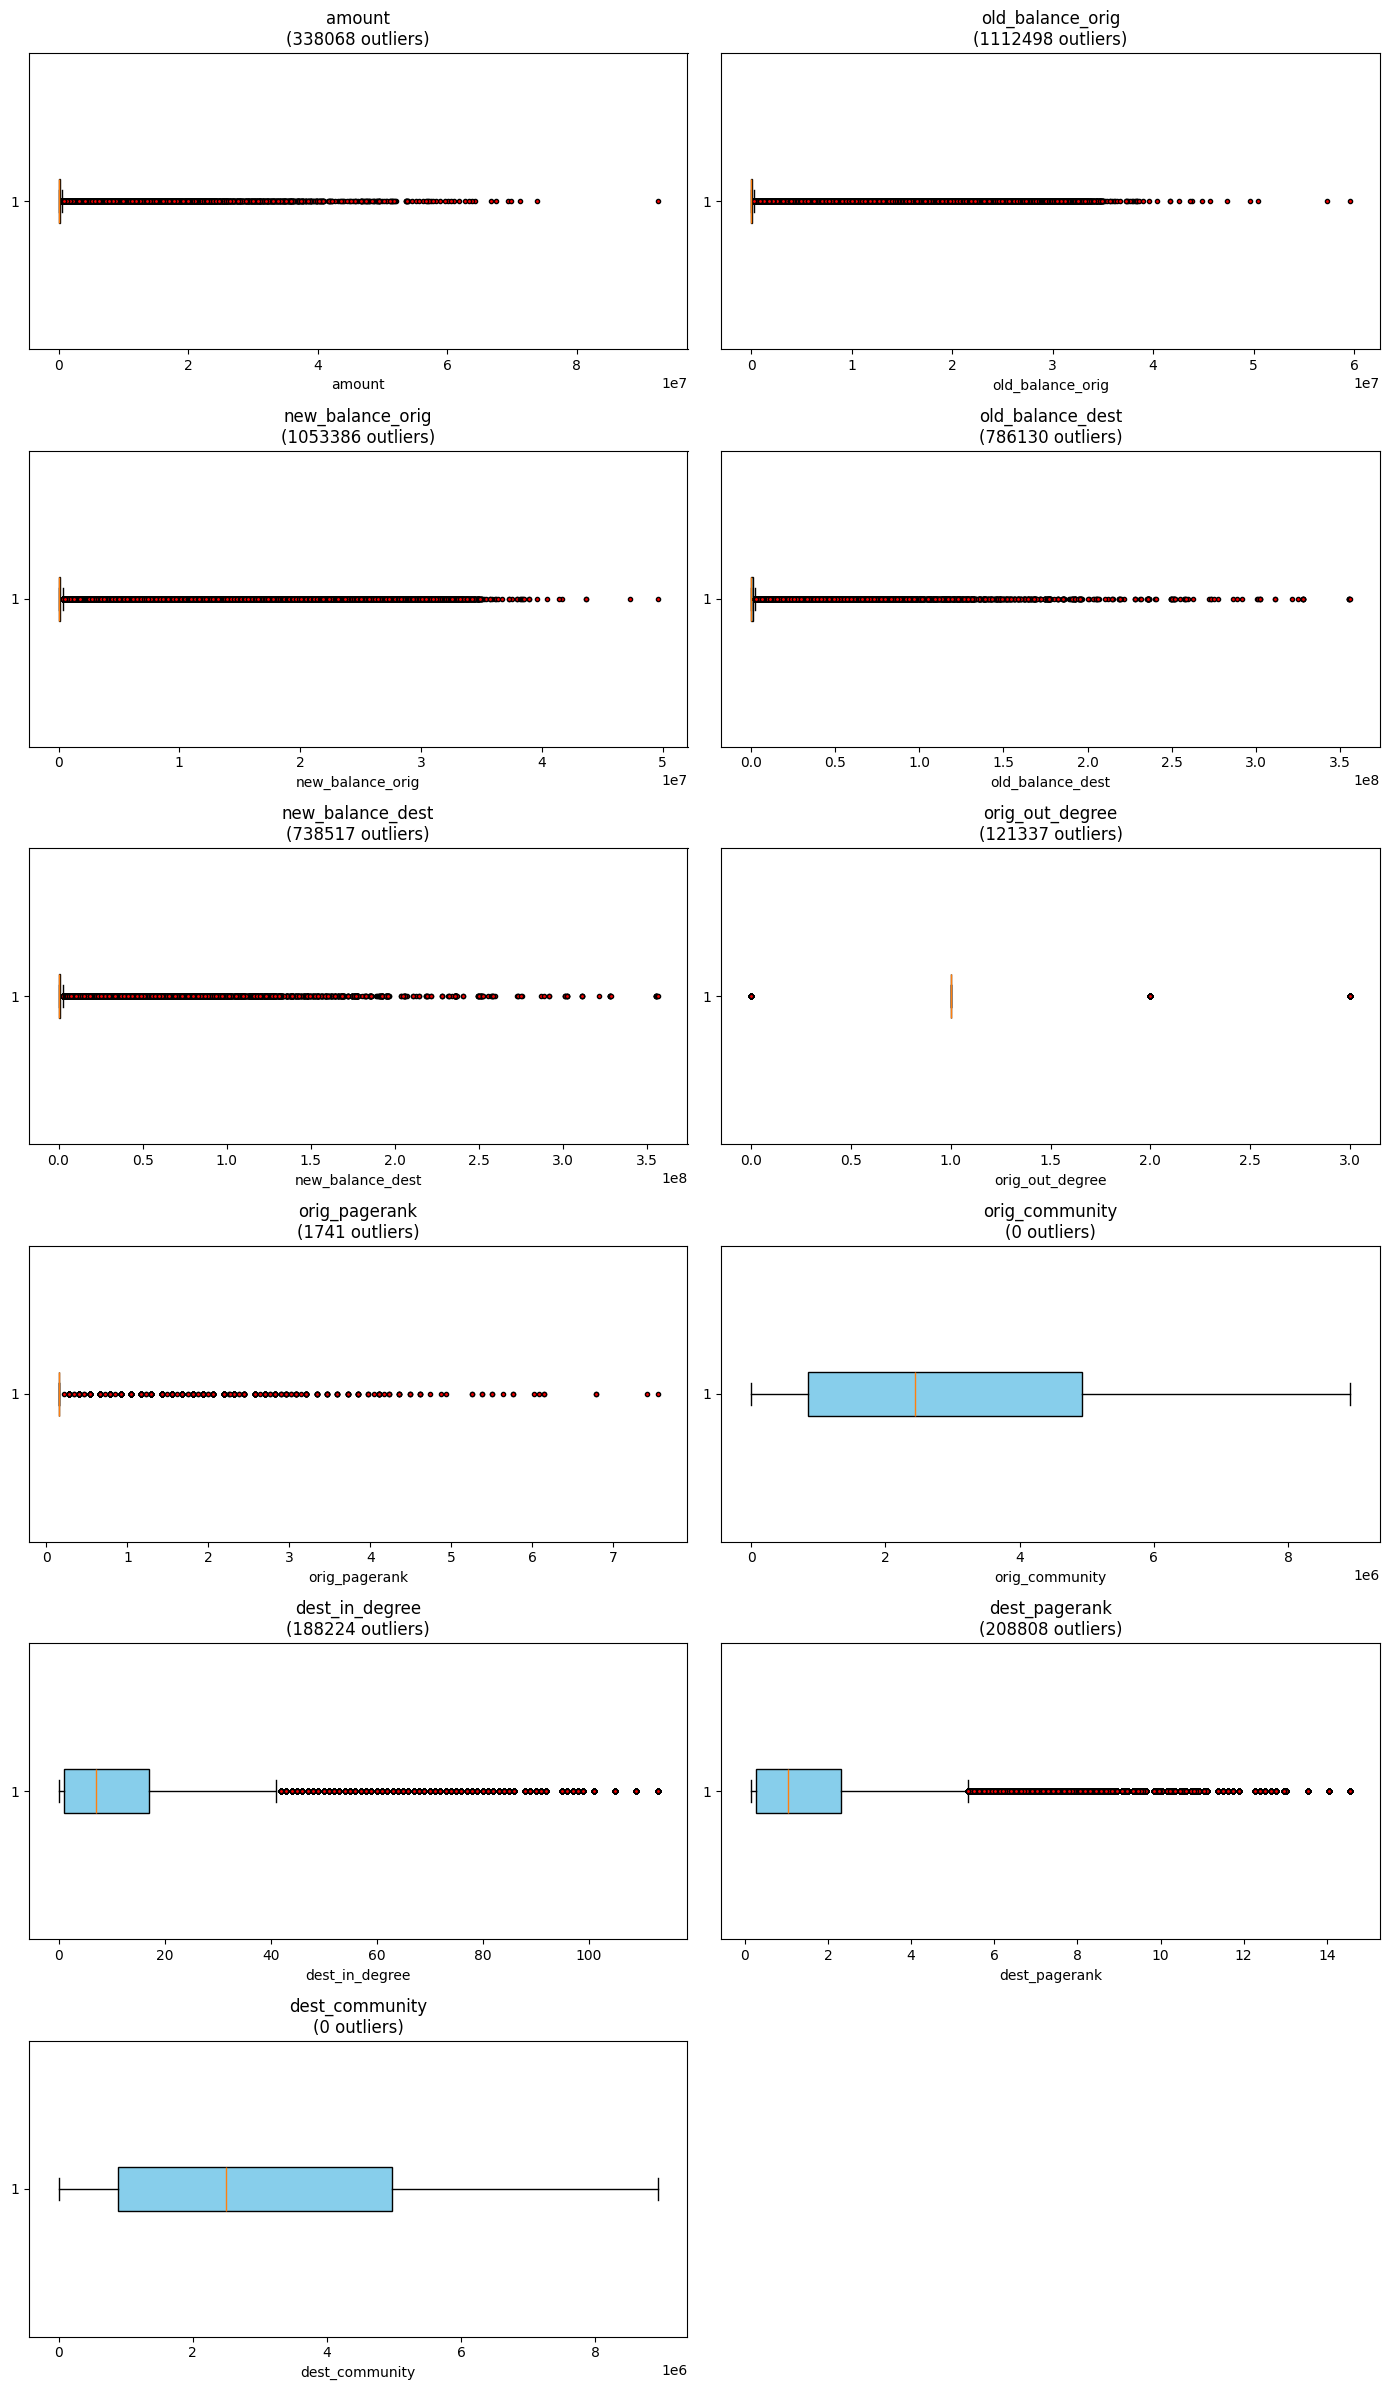

Resumen de outliers detectados: {'amount': 338068, 'old_balance_orig': 1112498, 'new_balance_orig': 1053386, 'old_balance_dest': 786130, 'new_balance_dest': 738517, 'orig_out_degree': 121337, 'orig_pagerank': 1741, 'orig_community': 0, 'dest_in_degree': 188224, 'dest_pagerank': 208808, 'dest_community': 0}


In [ ]:
import matplotlib.pyplot as plt
import math

# 1. Identificar columnas (excluimos el target y la marca de train)
columnas_numericas = df.select_dtypes(include=["float64", "int64"]).columns.drop(["is_fraud", "is_train"])

# 2. Calcular dimensiones de la cuadrícula dinámicamente
n_cols_plot = 2
n_rows_plot = math.ceil(len(columnas_numericas) / n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(14, n_rows_plot * 4))
axes = axes.flatten()

outliers_info = {}

for i, col in enumerate(columnas_numericas):
    # Cálculo de IQR para detectar outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    n_outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)].shape[0]
    outliers_info[col] = n_outliers

    # Dibujar Boxplot
    axes[i].boxplot(df[col], vert=False, patch_artist=True, 
                    boxprops=dict(facecolor="skyblue"),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=3))
    
    axes[i].set_title(f"{col}\n({n_outliers} outliers)", fontsize=12)
    axes[i].set_xlabel(col)

# 3. Eliminar ejes vacíos si el número de columnas es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("outliers_boxplot.png") # Recuerda usar savefig en entornos de ejecución
plt.show()

In [25]:

print("Resumen de outliers detectados:", outliers_info)

Resumen de outliers detectados: {'amount': 338068, 'old_balance_orig': 1112498, 'new_balance_orig': 1053386, 'old_balance_dest': 786130, 'new_balance_dest': 738517, 'orig_out_degree': 121337, 'orig_pagerank': 1741, 'orig_community': 0, 'dest_in_degree': 188224, 'dest_pagerank': 208808, 'dest_community': 0}


En este estudio se ha decidido conservar la totalidad de los valores atípicos, ya que en el ámbito de la detección de fraude, las transacciones anómalas no representan errores de medición, sino patrones de comportamiento sospechosos que el modelo debe identificar.

# Fase 3: División de los datos

In [26]:
df

,type,amount,old_balance_orig,new_balance_orig,old_balance_dest,new_balance_dest,orig_out_degree,orig_pagerank,orig_community,dest_in_degree,dest_pagerank,dest_community,is_fraud,is_train
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,1.0,0.15,53200.0,1.0,0.27750,53200.0,0,1
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,1.0,0.15,53201.0,1.0,0.27750,53201.0,0,1
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1.0,0.15,6013326.0,44.0,5.69625,6013326.0,1,1
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1.0,0.15,53203.0,41.0,5.37750,53203.0,1,1
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,1.0,0.15,53204.0,1.0,0.27750,53204.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,0.0,0.15,-1.0,1.0,0.27750,5302675.0,1,0
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,0.0,0.15,-1.0,0.0,0.15000,-1.0,1,0
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,0.0,0.15,-1.0,2.0,0.40500,3613266.0,1,0
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,0.0,0.15,-1.0,0.0,0.15000,-1.0,1,0


### Division de los datos

In [27]:
# 1. Separación física de los datos
train_df = df[df['is_train'] == 1].copy()
test_df = df[df['is_train'] == 0].copy()

# 2. Separar características (X) y etiqueta (y)
X_train = train_df.drop(columns=['is_fraud', 'is_train'])
y_train = train_df['is_fraud']

X_test = test_df.drop(columns=['is_fraud', 'is_train'])
y_test = test_df['is_fraud']

## Encoders

In [31]:

# Creamos el encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Ajustamos con TRAIN y transformamos ambos
train_types = encoder.fit_transform(X_train[['type']])
test_types = encoder.transform(X_test[['type']])

# Convertimos a DataFrame para volver a unirlos
train_types_df = pd.DataFrame(train_types, columns=encoder.get_feature_names_out(['type']), index=X_train.index)
test_types_df = pd.DataFrame(test_types, columns=encoder.get_feature_names_out(['type']), index=X_test.index)

# Unimos y eliminamos la columna 'type' original
X_train = pd.concat([X_train.drop(columns=['type']), train_types_df], axis=1)
X_test = pd.concat([X_test.drop(columns=['type']), test_types_df], axis=1)

## Escalado

In [36]:

# 1. Inicializamos el escalador
scaler = StandardScaler()

# 2. Ajustamos con Train y transformamos ambos
# Nota: Aquí usamos los DataFrames que ya tenemos (X_train y tu X_test recién mostrado)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Lo convertimos de nuevo a DataFrame para no perder los nombres de las columnas
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Escalado finalizado con éxito.")
print("Ejemplo de X_test_final (primeras 5 filas):")
print(X_test_final.head())

✅ Escalado finalizado con éxito.
Ejemplo de X_test_final (primeras 5 filas):
           amount  old_balance_orig  new_balance_orig  old_balance_dest  \
6259047 -0.297234         -0.288586         -0.292374         -0.324805   
6259048 -0.258885         -0.288604         -0.292374         -0.324805   
6259049 -0.293818         -0.274990         -0.279672         -0.324805   
6259050 -0.294935         -0.271485         -0.275981         -0.324805   
6259051 -0.290072         -0.288048         -0.292374         -0.324805   

         new_balance_dest  orig_out_degree  orig_pagerank  orig_community  \
6259047         -0.334116       -18.625129      -0.011313       -1.236036   
6259048         -0.334116       -18.625129      -0.011313       -1.236036   
6259049         -0.334116       -18.625129      -0.011313       -1.236036   
6259050         -0.334116       -18.625129      -0.011313       -1.236036   
6259051         -0.334116       -18.625129      -0.011313       -1.236036   

         

# Fase 4: Entrenamiento del modelo y realización de las predicciones

In [ ]:
# Inicializamos la lista global para guardar resultados
resultados_modelos = []

### Entrenamiento y validacion de Naive Bayes

⏳ Entrenando Naive Bayes...


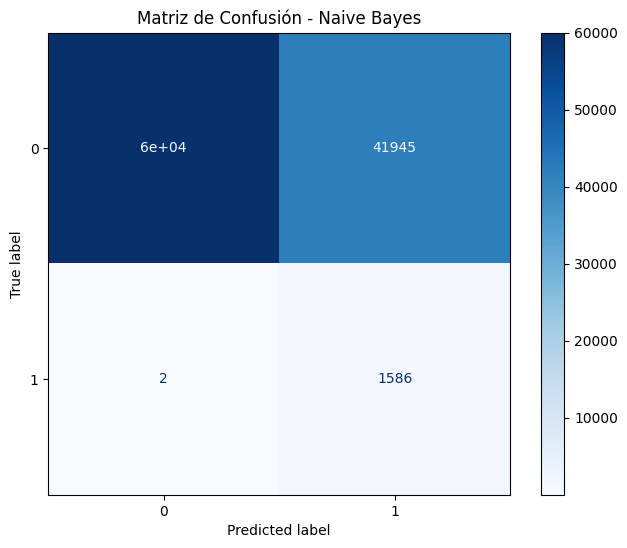

--- Resultados Naive Bayes ---
Exactitud: 0.5949
Precisión: 0.0364
Recall (Sensibilidad): 0.9987
F1-Score: 0.0703


In [ ]:

# 1. Inicialización del clasificador
clasificador_NB = GaussianNB()

# 2. Entrenamiento del clasificador (Usamos los datos escalados)
print("⏳ Entrenando Naive Bayes...")
clasificador_NB.fit(X_train_final, y_train)

# 3. Realización de las predicciones
predicciones_NB = clasificador_NB.predict(X_test_final)

# 4. Creación de la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones_NB, ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()

# 5. Cálculo de métricas de rendimiento
accuracy_NB = accuracy_score(y_test, predicciones_NB)
# Usamos average='binary' porque nuestro target es 0 o 1 (Fraude)
precision_NB = precision_score(y_test, predicciones_NB)
recall_NB = recall_score(y_test, predicciones_NB)
f1_NB = f1_score(y_test, predicciones_NB)

print(f"--- Resultados Naive Bayes ---")
print(f"Exactitud: {accuracy_NB:.4f}")
print(f"Precisión: {precision_NB:.4f}")
print(f"Recall (Sensibilidad): {recall_NB:.4f}")
print(f"F1-Score: {f1_NB:.4f}")

resultados_modelos.append({
    "id": "NB",
    "Modelo": "Naive Bayes",
    "Exactitud": accuracy_NB,
    "Precisión": precision_NB,
    "Recall": recall_NB,
    "F1-Score": f1_NB
})

### Entrenamiento y validacion de Regresión Logística

⏳ Entrenando Regresión Logística (esto puede tardar un poco más por el volumen de datos)...


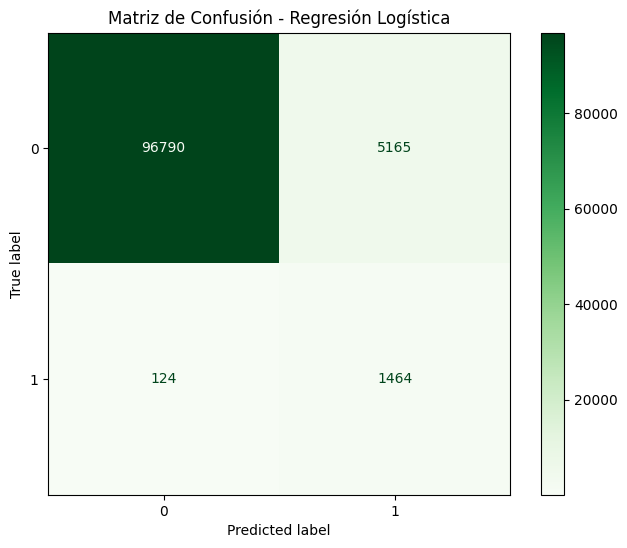

--- Resultados Regresión Logística ---
Exactitud: 0.9489
Precisión: 0.2208
Recall (Sensibilidad): 0.9219
F1-Score: 0.3563


In [39]:

# 1. Inicialización del clasificador
# 'max_iter' elevado para asegurar convergencia con 6M de datos
# 'class_weight' compensa el desbalanceo automáticamente
clasificador_LR = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# 2. Entrenamiento del clasificador
print("⏳ Entrenando Regresión Logística (esto puede tardar un poco más por el volumen de datos)...")
clasificador_LR.fit(X_train_final, y_train)

# 3. Realización de las predicciones
predicciones_LR = clasificador_LR.predict(X_test_final)

# 4. Creación de la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones_LR, ax=ax, cmap='Greens')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# 5. Cálculo de métricas de rendimiento
accuracy_LR = accuracy_score(y_test, predicciones_LR)
precision_LR = precision_score(y_test, predicciones_LR)
recall_LR = recall_score(y_test, predicciones_LR)
f1_LR = f1_score(y_test, predicciones_LR)

print(f"--- Resultados Regresión Logística ---")
print(f"Exactitud: {accuracy_LR:.4f}")
print(f"Precisión: {precision_LR:.4f}")
print(f"Recall (Sensibilidad): {recall_LR:.4f}")
print(f"F1-Score: {f1_LR:.4f}")

### Entrenamiento y validacion de Árbol de Decisión

⏳ Entrenando Árbol de Decisión...


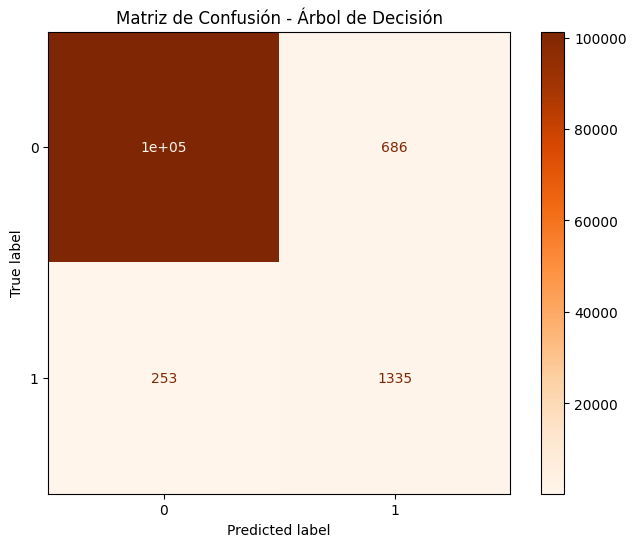

--- Resultados Árbol de Decisión ---
Exactitud: 0.9909
Precisión: 0.6606
Recall (Sensibilidad): 0.8407
F1-Score: 0.7398


In [40]:

# 1. Inicialización del clasificador
# Usamos class_weight='balanced' para combatir el desbalanceo
clasificador_DT = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10)

# 2. Entrenamiento
print("⏳ Entrenando Árbol de Decisión...")
clasificador_DT.fit(X_train_final, y_train)

# 3. Predicciones
predicciones_DT = clasificador_DT.predict(X_test_final)

# 4. Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones_DT, ax=ax, cmap='Oranges')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

# 5. Métricas
accuracy_DT = accuracy_score(y_test, predicciones_DT)
precision_DT = precision_score(y_test, predicciones_DT)
recall_DT = recall_score(y_test, predicciones_DT)
f1_DT = f1_score(y_test, predicciones_DT)

print(f"--- Resultados Árbol de Decisión ---")
print(f"Exactitud: {accuracy_DT:.4f}")
print(f"Precisión: {precision_DT:.4f}")
print(f"Recall (Sensibilidad): {recall_DT:.4f}")
print(f"F1-Score: {f1_DT:.4f}")

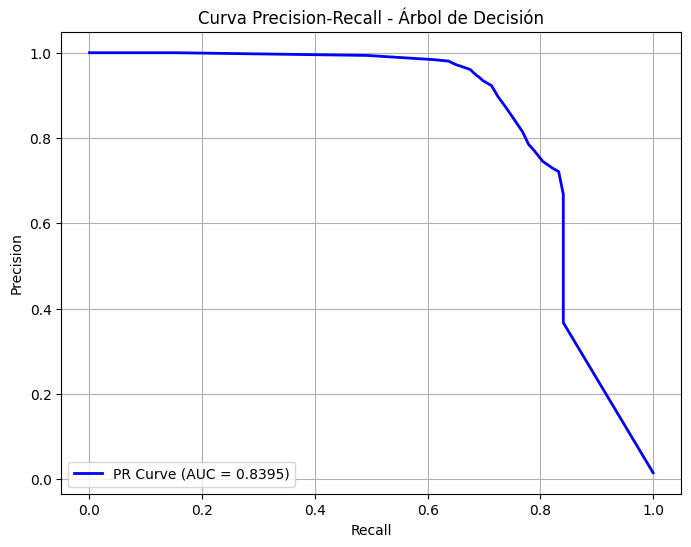

✅ PR-AUC: 0.8395


In [49]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1️⃣ Obtener probabilidades de predicción (no solo etiquetas)
# DecisionTreeClassifier tiene predict_proba, tomamos la probabilidad de la clase "1" (fraude)
probs_DT = clasificador_DT.predict_proba(X_test_final)[:, 1]

# 2️⃣ Calcular precision, recall y thresholds
precision, recall, thresholds = precision_recall_curve(y_test, probs_DT)

# 3️⃣ Calcular PR-AUC
pr_auc = auc(recall, precision)

# 4️⃣ Graficar la curva Precision-Recall
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='b', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Árbol de Decisión')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"✅ PR-AUC: {pr_auc:.4f}")

✅ Mejor Threshold: 0.98
✅ Mejor F1-Score: 0.8047


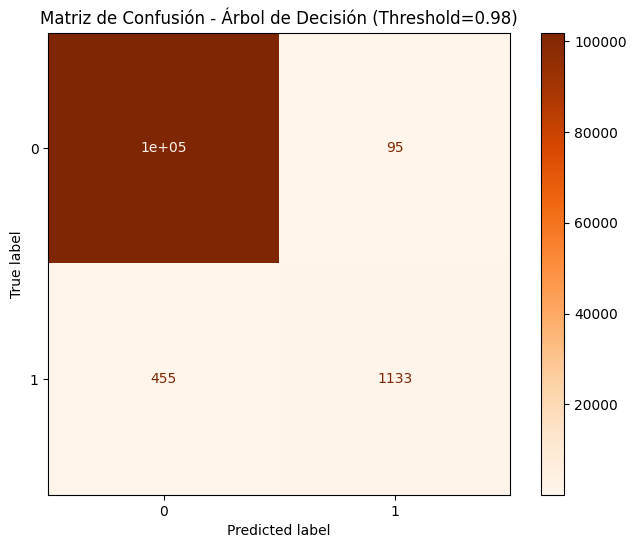

Precision: 0.9226
Recall: 0.7135
Accuracy: 0.9947


In [50]:
from sklearn.metrics import f1_score
import numpy as np

# 1️⃣ Probabilidades de predicción (clase fraude)
probs_DT = clasificador_DT.predict_proba(X_test_final)[:, 1]

# 2️⃣ Explorar thresholds
thresholds = np.linspace(0, 1, 101)  # de 0 a 1 en pasos de 0.01
f1_scores = []

for t in thresholds:
    preds = (probs_DT >= t).astype(int)  # predicción usando el threshold
    f1 = f1_score(y_test, preds)
    f1_scores.append(f1)

# 3️⃣ Encontrar threshold óptimo
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"✅ Mejor Threshold: {best_threshold:.2f}")
print(f"✅ Mejor F1-Score: {best_f1:.4f}")

# 4️⃣ Aplicar el threshold para predicciones finales
predicciones_optimas = (probs_DT >= best_threshold).astype(int)

# 5️⃣ Matriz de Confusión y métricas finales
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score

fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones_optimas, ax=ax, cmap='Oranges')
plt.title(f'Matriz de Confusión - Árbol de Decisión (Threshold={best_threshold:.2f})')
plt.show()

precision_opt = precision_score(y_test, predicciones_optimas)
recall_opt = recall_score(y_test, predicciones_optimas)
accuracy_opt = accuracy_score(y_test, predicciones_optimas)

print(f"Precision: {precision_opt:.4f}")
print(f"Recall: {recall_opt:.4f}")
print(f"Accuracy: {accuracy_opt:.4f}")

In [52]:
import pandas as pd

# Probabilidades de fraude
y_scores = clasificador_DT.predict_proba(X_test_final)[:, 1]

# Calculamos precision, recall y thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Creamos DataFrame con thresholds
df_thresholds = pd.DataFrame({
    'Threshold': np.append(thresholds, 1.0),  # añadimos 1.0 para que coincida con el tamaño de precision/recall
    'Precision': precision,
    'Recall': recall
})

# Mostramos los primeros 10 y últimos 10 para tener idea de extremos
pd.set_option('display.float_format', '{:.4f}'.format)
print("🔹 Tabla de Thresholds vs Precision/Recall")
print(df_thresholds.head(10))
print("...")
print(df_thresholds.tail(10))

🔹 Tabla de Thresholds vs Precision/Recall
   Threshold  Precision  Recall
0     0.0000     0.0153  1.0000
1     0.0154     0.3672  0.8407
2     0.6955     0.6606  0.8407
3     0.8112     0.6648  0.8407
4     0.9069     0.6682  0.8407
5     0.9458     0.7212  0.8325
6     0.9517     0.7297  0.8212
7     0.9619     0.7455  0.8042
8     0.9689     0.7714  0.7884
9     0.9703     0.7854  0.7790
...
    Threshold  Precision  Recall
20     0.9921     0.9726  0.6492
21     0.9976     0.9806  0.6366
22     0.9983     0.9806  0.6354
23     0.9992     0.9838  0.6108
24     0.9992     0.9878  0.5623
25     0.9998     0.9936  0.4924
26     0.9999     1.0000  0.1505
27     1.0000     1.0000  0.0989
28     1.0000     1.0000  0.0365
29     1.0000     1.0000  0.0000


### Entrenamiento y validacion de Random Forest

⏳ Entrenando Random Forest (con 6M de filas esto puede tardar unos minutos)...


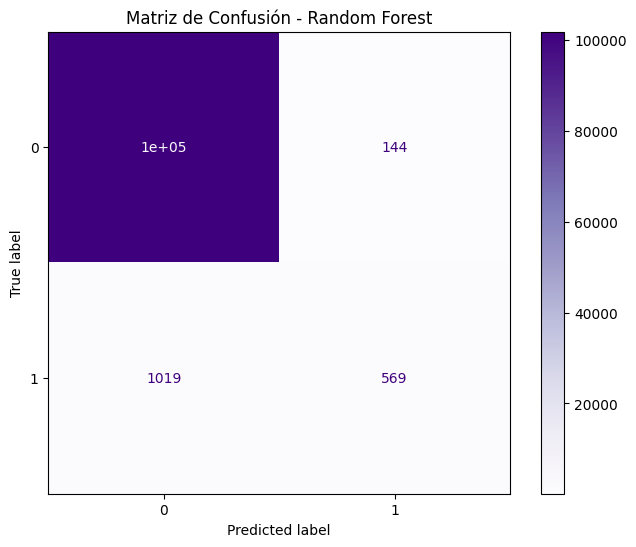

--- Resultados Random Forest ---
Exactitud: 0.9888
Precisión: 0.7980
Recall (Sensibilidad): 0.3583
F1-Score: 0.4946


In [41]:

# 1. Inicialización del clasificador
# 'n_estimators=100' crea 100 árboles diferentes
# 'max_depth=15' le damos un poco más de libertad que al árbol individual
clasificador_RF = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', n_jobs=-1, random_state=42)

# 2. Entrenamiento
print("⏳ Entrenando Random Forest (con 6M de filas esto puede tardar unos minutos)...")
clasificador_RF.fit(X_train_final, y_train)

# 3. Predicciones
predicciones_RF = clasificador_RF.predict(X_test_final)

# 4. Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones_RF, ax=ax, cmap='Purples')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# 5. Métricas
accuracy_RF = accuracy_score(y_test, predicciones_RF)
precision_RF = precision_score(y_test, predicciones_RF)
recall_RF = recall_score(y_test, predicciones_RF)
f1_RF = f1_score(y_test, predicciones_RF)

print(f"--- Resultados Random Forest ---")
print(f"Exactitud: {accuracy_RF:.4f}")
print(f"Precisión: {precision_RF:.4f}")
print(f"Recall (Sensibilidad): {recall_RF:.4f}")
print(f"F1-Score: {f1_RF:.4f}")

⏳ Entrenando LightGBM (esto será sorprendentemente rápido)...


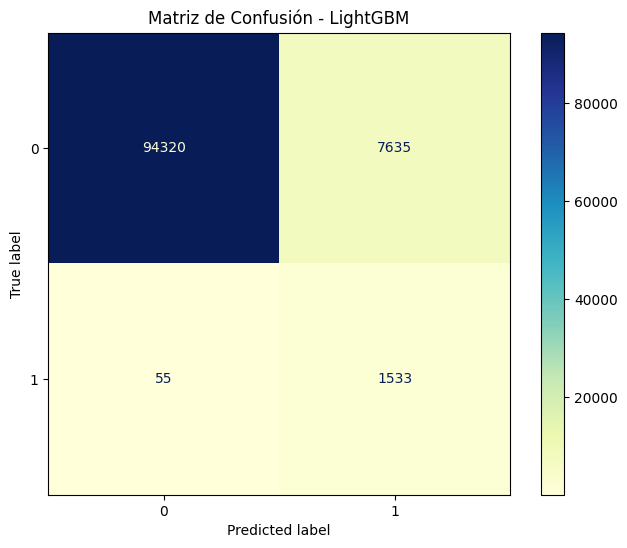

--- Resultados LightGBM ---
Exactitud: 0.9257
Precisión: 0.1672
Recall (Sensibilidad): 0.9654
F1-Score: 0.2851


In [42]:
from lightgbm import LGBMClassifier

# 1. Inicialización del clasificador
# is_unbalance=True ayuda mucho cuando la clase positiva es muy pequeña
clasificador_LGBM = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=10,
    is_unbalance=True, 
    random_state=42,
    n_jobs=-1,
    verbosity=-1 # Para evitar mensajes innecesarios
)

# 2. Entrenamiento
print("⏳ Entrenando LightGBM (esto será sorprendentemente rápido)...")
clasificador_LGBM.fit(X_train_final, y_train)

# 3. Predicciones
predicciones_LGBM = clasificador_LGBM.predict(X_test_final)

# 4. Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones_LGBM, ax=ax, cmap='YlGnBu')
plt.title('Matriz de Confusión - LightGBM')
plt.show()

# 5. Métricas
accuracy_LGB = accuracy_score(y_test, predicciones_LGBM)
precision_LGB = precision_score(y_test, predicciones_LGBM)
recall_LGB = recall_score(y_test, predicciones_LGBM)
f1_LGB = f1_score(y_test, predicciones_LGBM)

print(f"--- Resultados LightGBM ---")
print(f"Exactitud: {accuracy_LGB:.4f}")
print(f"Precisión: {precision_LGB:.4f}")
print(f"Recall (Sensibilidad): {recall_LGB:.4f}")
print(f"F1-Score: {f1_LGB:.4f}")

In [45]:

# Creamos el diccionario usando las variables que ya tienes en memoria
data_final = {
    "Modelo": ["Naive Bayes", "Regresión Logística", "Árbol de Decisión", "Random Forest", "LightGBM"],
    "Exactitud": [accuracy_NB, accuracy_LR, accuracy_DT, accuracy_RF, accuracy_LGB],
    "Precisión": [precision_NB, precision_LR, precision_DT, precision_RF, precision_LGB],
    "Recall": [recall_NB, recall_LR, recall_DT, recall_RF, recall_LGB],
    "F1-Score": [f1_NB, f1_LR, f1_DT, f1_RF, f1_LGB]
}

# Creamos el DataFrame
df_comparativa = pd.DataFrame(data_final)

# Ordenamos por F1-Score para resaltar al mejor
df_comparativa = df_comparativa.sort_values(by="F1-Score", ascending=False)

# Mostramos la tabla formateada
print("🏆 COMPARATIVA FINAL DE RENDIMIENTO")
print("-" * 40)
print(df_comparativa.to_string(index=False))

# Opcional: Si estás en un Notebook, usa solo df_comparativa para verla con estilo visual
# df_comparativa

🏆 COMPARATIVA FINAL DE RENDIMIENTO
----------------------------------------
             Modelo  Exactitud  Precisión   Recall  F1-Score
  Árbol de Decisión   0.990931   0.660564 0.840680  0.739817
      Random Forest   0.988768   0.798036 0.358312  0.494568
Regresión Logística   0.948920   0.220848 0.921914  0.356334
           LightGBM   0.925731   0.167212 0.965365  0.285050
        Naive Bayes   0.594883   0.036434 0.998741  0.070303


✅ MODELO FINAL: Random Forest Optimizado (Umbral: 0.15)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    101955
           1       0.44      0.99      0.61      1588

    accuracy                           0.98    103543
   macro avg       0.72      0.99      0.80    103543
weighted avg       0.99      0.98      0.98    103543



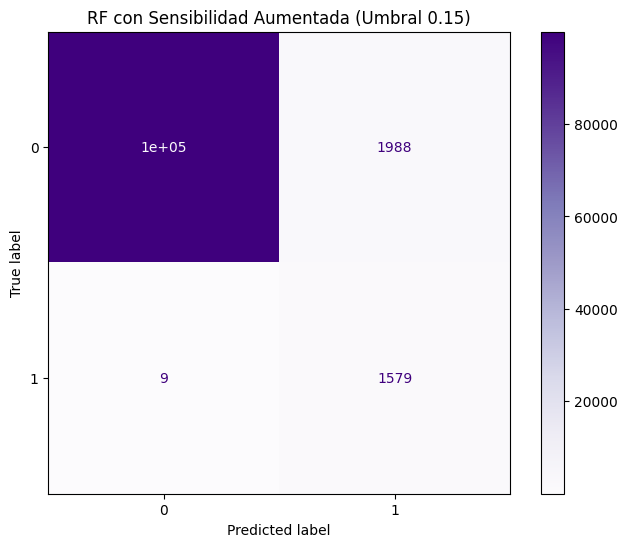

In [53]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Obtenemos las probabilidades (no las etiquetas fijas)
# Esto nos da la probabilidad de 0 a 1 para cada transaccion
probs_RF = clasificador_RF.predict_proba(X_test_final)[:, 1]

# 2. AJUSTE DE UMBRAL (THRESHOLD TUNING)
# Bajamos el umbral al 15% para atrapar más fraudes
umbral_sensible = 0.15
predicciones_finales = (probs_RF >= umbral_sensible).astype(int)

# 3. Ver resultados
print(f"✅ MODELO FINAL: Random Forest Optimizado (Umbral: {umbral_sensible})")
print("-" * 60)
print(classification_report(y_test, predicciones_finales))

# 4. Matriz de Confusión para validar visualmente
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predicciones_finales, ax=ax, cmap='Purples')
plt.title(f'RF con Sensibilidad Aumentada (Umbral {umbral_sensible})')
plt.show()

📊 RANKING DE VARIABLES (Importancia para el Modelo)
--------------------------------------------------
1. old_balance_orig: 0.3174
2. new_balance_orig: 0.1753
3. amount: 0.1527
4. type_PAYMENT: 0.0752
5. type_TRANSFER: 0.0744
6. new_balance_dest: 0.0604
7. old_balance_dest: 0.0384
8. type_CASH_IN: 0.0329
9. type_CASH_OUT: 0.0281
10. orig_community: 0.0150
11. dest_community: 0.0110
12. dest_pagerank: 0.0099
13. dest_in_degree: 0.0089
14. type_DEBIT: 0.0004
15. orig_out_degree: 0.0000
16. orig_pagerank: 0.0000


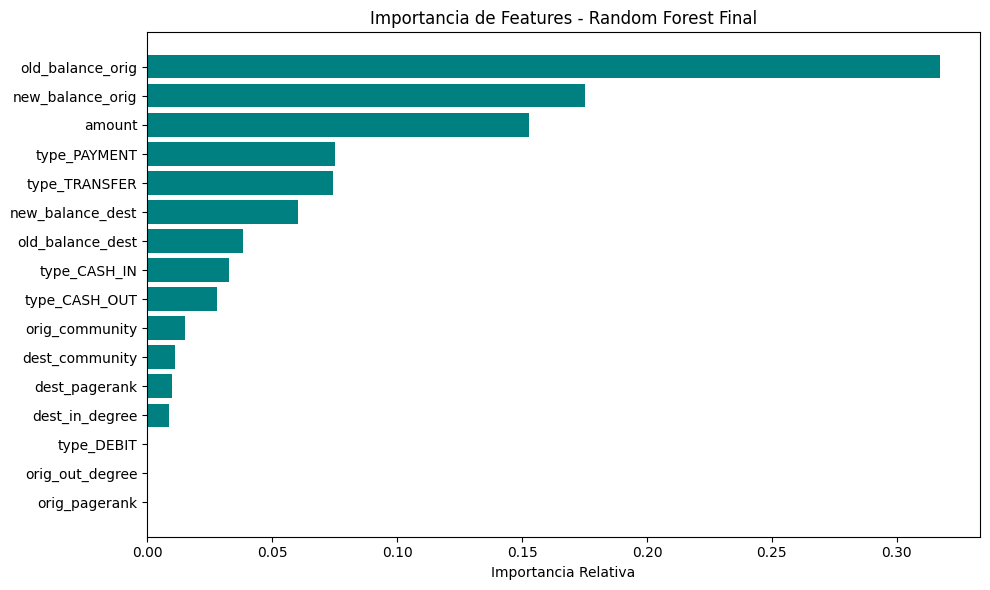

In [54]:
# Ver qué variables son las reinas del modelo final
importancias = clasificador_RF.feature_importances_
nombres = X_train_final.columns
indices = np.argsort(importancias)[::-1]

print("📊 RANKING DE VARIABLES (Importancia para el Modelo)")
print("-" * 50)
for i in range(len(indices)):
    print(f"{i+1}. {nombres[indices[i]]}: {importancias[indices[i]]:.4f}")

# Gráfico para tu TFG
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.title("Importancia de Features - Random Forest Final")
plt.barh(range(len(indices)), importancias[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [nombres[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.gca().invert_yaxis() # Poner la más importante arriba
plt.tight_layout()
plt.show()

### Importación del modelo 

In [55]:
import joblib

# 1. Creamos un diccionario con todo lo necesario
# Es importante guardar también el escalador (scaler) para que los datos 
# nuevos se transformen igual que los de entrenamiento.
objeto_modelo = {
    'modelo': clasificador_RF,
    'scaler': scaler,
    'features': X_train_final.columns.tolist(),
    'umbral': 0.15
}

# 2. Guardar en el disco
nombre_archivo = 'modelo_fraude_rf_final.joblib'
joblib.dump(objeto_modelo, nombre_archivo)

print(f"✅ ¡Modelo guardado con éxito como '{nombre_archivo}'!")
print("📦 El archivo incluye: Modelo RF, Escalador, nombres de variables y el umbral de 0.15.")

✅ ¡Modelo guardado con éxito como 'modelo_fraude_rf_final.joblib'!
📦 El archivo incluye: Modelo RF, Escalador, nombres de variables y el umbral de 0.15.


In [56]:
import joblib
from sklearn.metrics import classification_report, f1_score

# 1. Cargar el "paquete" del modelo
print("📥 Cargando modelo desde el archivo...")
datos_cargados = joblib.load('modelo_fraude_rf_final.joblib')

modelo_recuperado = datos_cargados['modelo']
scaler_recuperado = datos_cargados['scaler']
umbral_recuperado = datos_cargados['umbral']
features_esperadas = datos_cargados['features']

# 2. Asegurarnos de que las columnas están en el orden correcto
# (Es vital que el orden de X_test_final sea igual al que guardamos)
X_test_verif = X_test_final[features_esperadas]

# 3. Hacer la predicción con el modelo cargado
# Obtenemos probabilidades y aplicamos el umbral guardado (0.15)
probs_nuevas = modelo_recuperado.predict_proba(X_test_verif)[:, 1]
predicciones_nuevas = (probs_nuevas >= umbral_recuperado).astype(int)

# 4. Mostrar métricas para comparar
print("\n✅ PRUEBA DE INTEGRIDAD POST-CARGA")
print("-" * 50)
print(classification_report(y_test, predicciones_nuevas))

# 5. Verificación técnica (Comparación de F1-Score)
f1_nuevo = f1_score(y_test, predicciones_nuevas)
print(f"F1-Score del modelo cargado: {f1_nuevo:.4f}")

# Si este F1-Score es igual al que tenías antes (0.61 aproximadamente), 
# el modelo está perfecto.

📥 Cargando modelo desde el archivo...

✅ PRUEBA DE INTEGRIDAD POST-CARGA
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    101955
           1       0.44      0.99      0.61      1588

    accuracy                           0.98    103543
   macro avg       0.72      0.99      0.80    103543
weighted avg       0.99      0.98      0.98    103543

F1-Score del modelo cargado: 0.6126
